# Setup

导入 `track` 并切到全局区域。所有 hotspot 统计均在 `global` 下进行。

In [1]:
%matplotlib inline
import importlib
import track

track.switch_region('global')

[RegionConfig] Switched to region 'global': lon[-180.0, 180.0], lat[-90.0, 90.0]


# Detection Method

三种 DO 异常检测方法之一，本 notebook 只在此 cell 与 AOU/DO 版不同。`trim` 采用一篇全球自适应文章的算法（截断 z-score 1.96、200–1000 m 深度窗）。与 `aou` 类似偏好大西洋/南大洋通风区。注意：`do`/`aou`/`trim` 是三个探测**不同物理量**的独立检测器，不是同一信号的三档阈值；它们各自偏好的区域不同是真物理，不是阈值越拧越紧的收敛。

In [2]:
det_cfg = track.make_detection_config(
    'trim',
    trim_cutoff=1.96,
    trim_depth_min=200.0,
    trim_depth_max=1000.0,
    anomaly_min_depth=300.0,
    cbar_min=2.0,
    cbar_max=6.0,
)

print(det_cfg.method, det_cfg.file_stem())

trim trim1p96_depth300m


# Plot Argo Hotspots

全球 Argo DO 异常热点总图（2002–2023），三方法对照的“全球画布”。下方为 run-once 的多年多进程重活，输出已存在于 `plot_outputs/<method>/global_ocean/plot_argo_hotspots/`（`hotspot_type` 拆分产出 `_non_nearshore` 与 `_type3` 两图 + anomalies parquet），**请勿重跑**。

In [ ]:
track.switch_region('global')

# run-once：全球 hotspot 总图（2002–2023，多年多进程重活）。
# 输出已存在于 plot_outputs/<method>/global_ocean/plot_argo_hotspots/，请勿重跑。
track.plot_argo_hotspots(
    start_year=2002,
    end_year=2023,
    dask_workers=8,
    save_fig=True,
    show_fig=True,
    save_data=True,
    split_plots='hotspot_type',
    detection_config=det_cfg,
)

## Anomaly Diagnostics

轻量抽查：重绘单条黑潮延伸体热点剖面（Profile 55867 / 2014，143.8°E, 32.5°N），按当前方法标注判别变量与辅助 ΔT/ΔS。可直接执行。

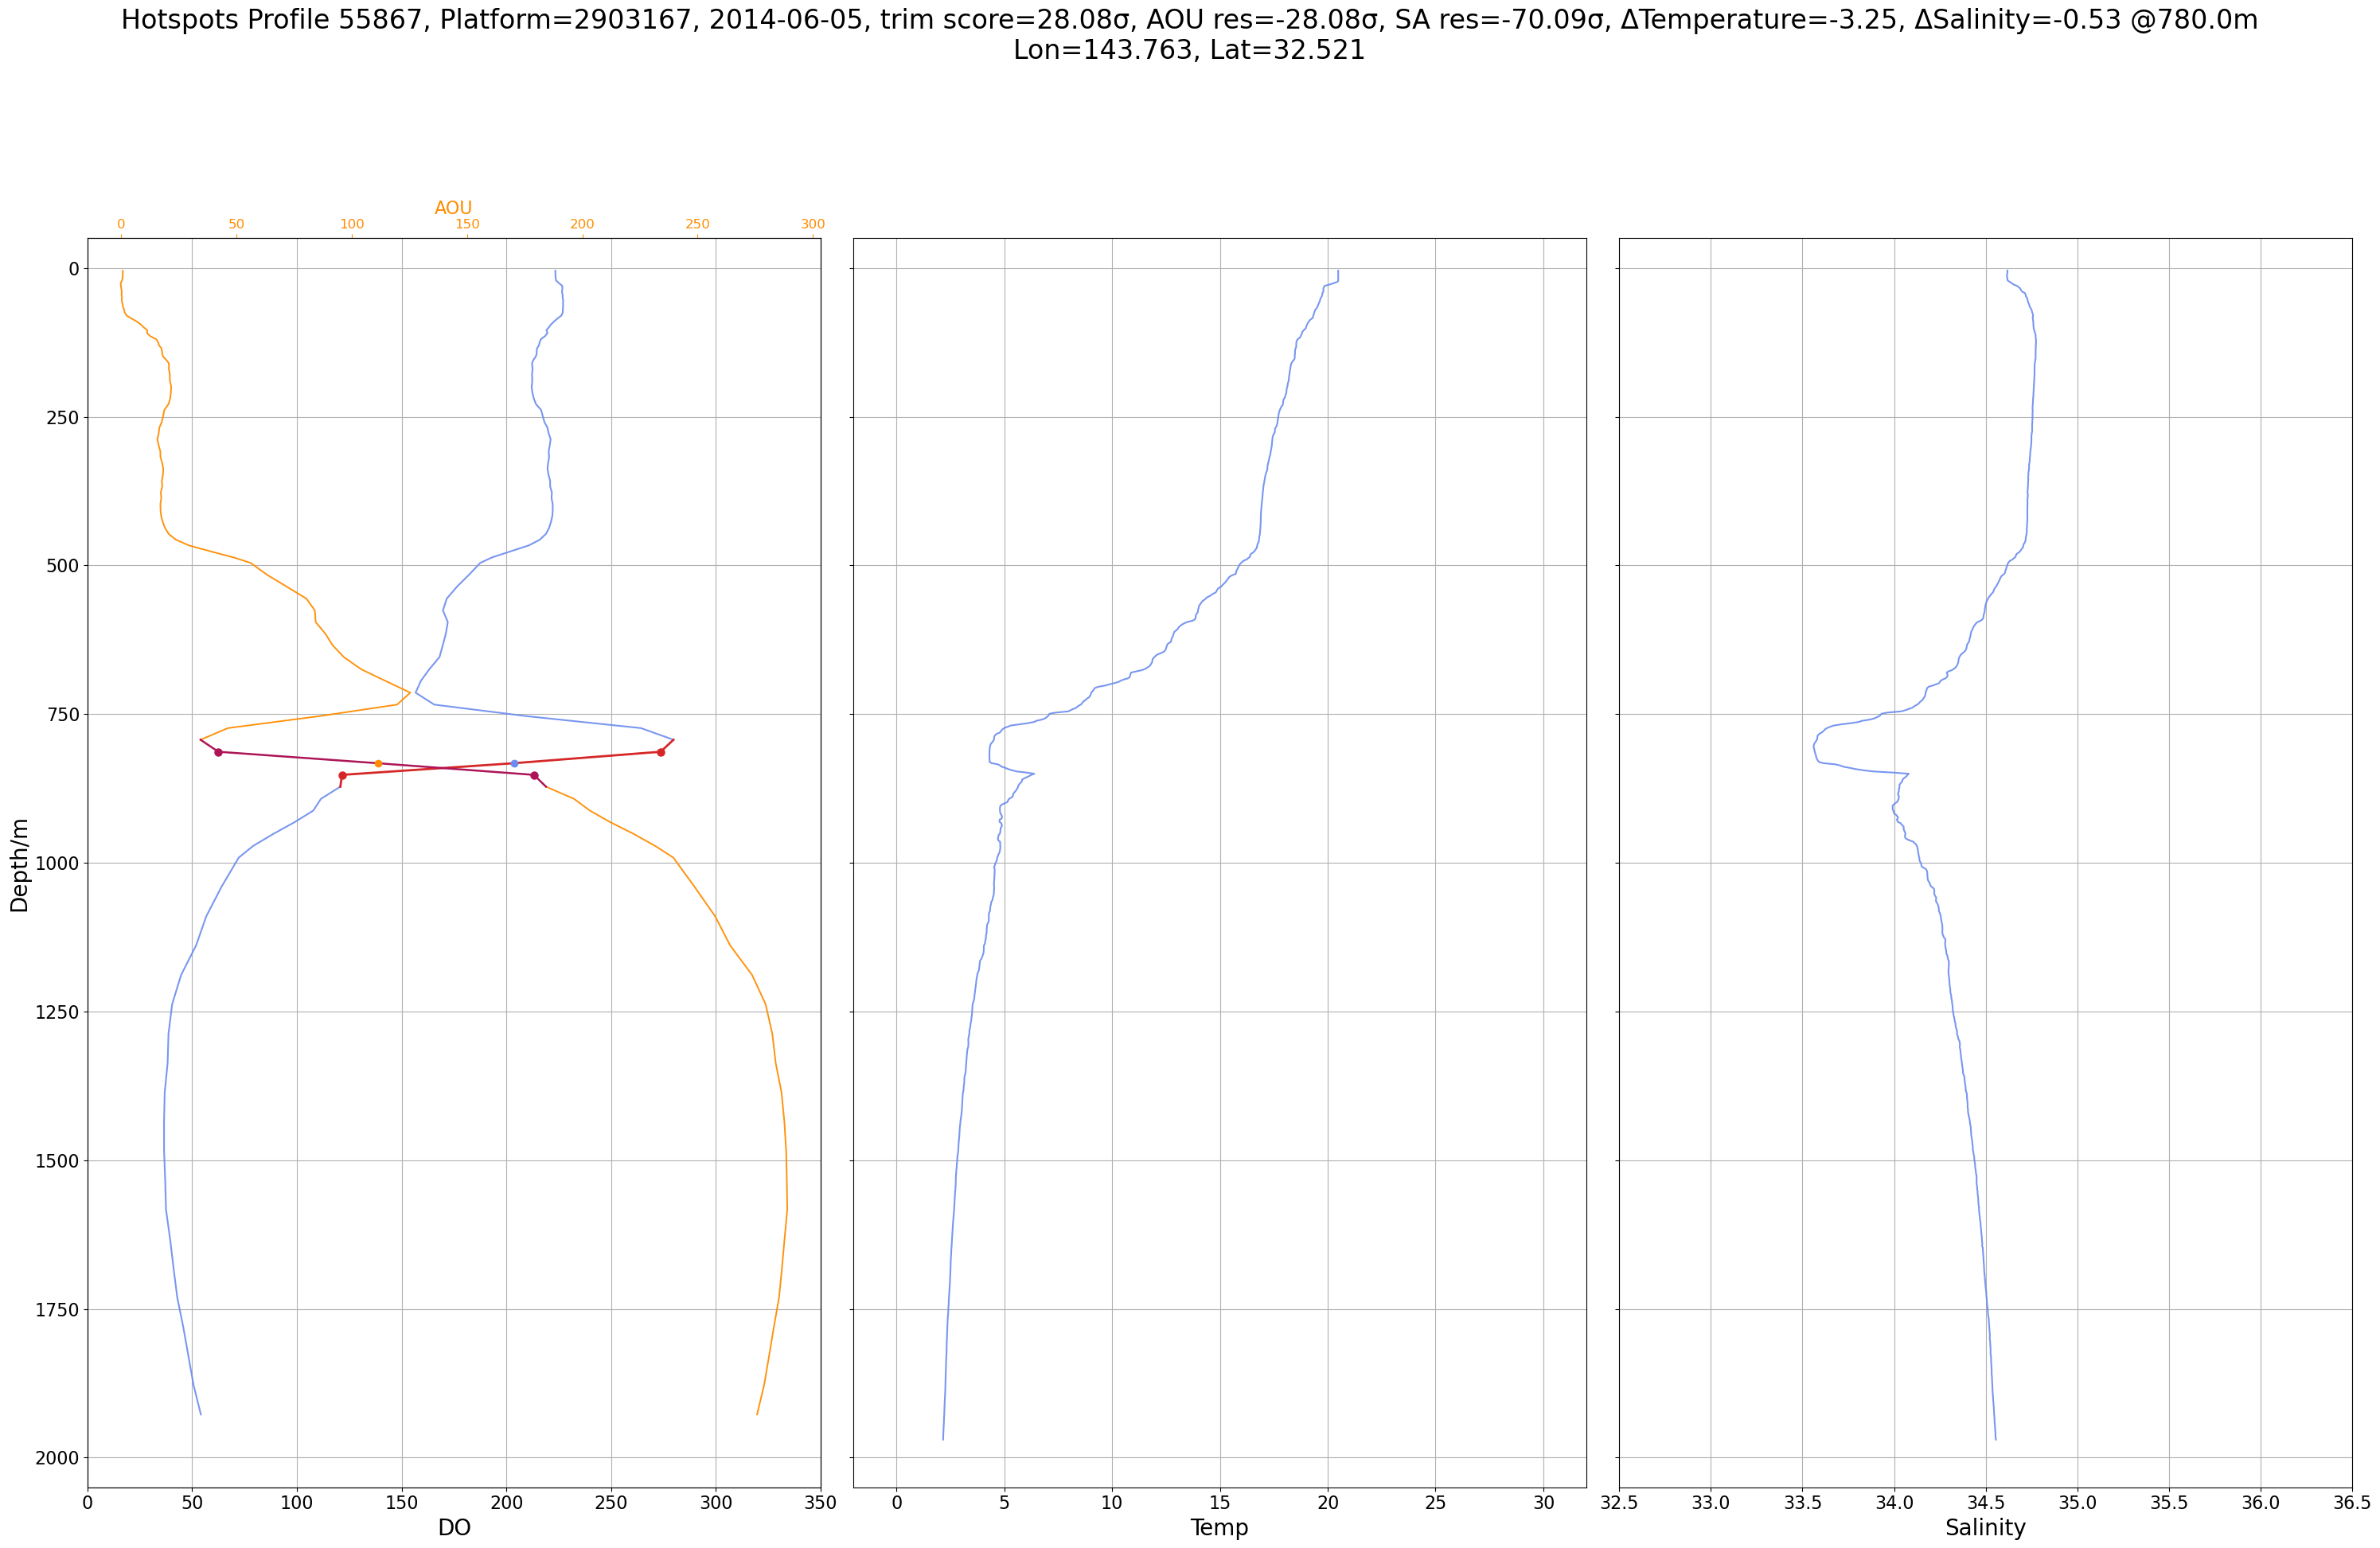

{'profile_number': 55867,
 'platform_number': 2903167,
 'date': '2014-06-05',
 'delta_do': 128.77284703493714,
 'delta_temperature': -3.2536668424951545,
 'delta_salinity': -0.529267490253126,
 'delta_aou': -105.88543640968268,
 'delta_pi': nan,
 'trim_score': 28.0805794429596,
 'anomaly_score': 28.0805794429596,
 'primary_metric': 'trim_score',
 'primary_value': 28.0805794429596,
 'detection_method': 'trim',
 'save_path': None}

In [3]:
track.plot_single_hotspot_profile(
    55867,
    2014,
    detection_config=det_cfg,
    remove_outliers=False,
)

# Frequency Analysis

三方法稳健性对照：在相同的 Argo–涡邻近关系下，统计携异常剖面在涡内/涡外的出现频率。依赖 `export_all_interacting_argo` 预生成的 **shared（方法无关）** 交互缓存 `all_interacting_argo_<years>.parquet`——它全局只需跑一次、已在 `GLORYS.ipynb` 跑过并落盘，故本 notebook 不重复。本 cell 只读该缓存 + 本方法的 anomalies parquet，**可快速重复执行**（非 run-once）。

In [4]:
track.switch_region('global')

# 读取 export_all_interacting_argo 的 shared 交互缓存 + 本方法 anomalies，快速出对照统计（可重复跑）。
track.calculate_interaction_statistics(
    start_year=2002,
    end_year=2023,
    detection_config=det_cfg,
    save_report=True,
)

[RegionConfig] Switched to region 'global': lon[-180.0, 180.0], lat[-90.0, 90.0]
--- Calculating Interaction Statistics 2002-2023 ---
[*] Loading precomputed interactions from: plot_outputs/shared/global_ocean/statistics/all_interacting_argo_2002_2023.parquet
[*] Loaded 108695 unique interacting profiles.
[*] Loading precomputed region profiles from: plot_outputs/shared/global_ocean/statistics/all_region_argo_2002_2023.parquet
[*] Loaded 269008 region profiles (Strictly inside region).
[*] Found default precomputed anomalies file: plot_outputs/trim/global_ocean/plot_argo_hotspots/anomalies_2002_2023_trim1p96_depth300m.parquet
[*] Loading precomputed anomalies from: plot_outputs/trim/global_ocean/plot_argo_hotspots/anomalies_2002_2023_trim1p96_depth300m.parquet
[*] Method=trim, records=27695
[*] Loaded 27695 anomalies (filtered by region).
Interaction Statistics Report (2002-2023)
Region: global_ocean
Source: Precomputed File (all_interacting_argo_2002_2023.parquet)
Method: trim
Criteri